In [8]:
import pandas as pd
import numpy as np

Df = pd.read_csv("https://raw.githubusercontent.com/EvidenceN/DataSets/master/Life%20Expectancy%20Data.csv")

Df.info()
Df.head()
Df.describe()
Df_model.columns.tolist()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2938 entries, 0 to 2937
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          2938 non-null   object 
 1   Year                             2938 non-null   int64  
 2   Status                           2938 non-null   object 
 3   Life expectancy                  2928 non-null   float64
 4   Adult Mortality                  2928 non-null   float64
 5   infant deaths                    2938 non-null   int64  
 6   Alcohol                          2744 non-null   float64
 7   percentage expenditure           2938 non-null   float64
 8   Hepatitis B                      2385 non-null   float64
 9   Measles                          2938 non-null   int64  
 10   BMI                             2904 non-null   float64
 11  under-five deaths                2938 non-null   int64  
 12  Polio               

['Year',
 'Status',
 'Life expectancy',
 'Adult Mortality',
 'infant deaths',
 'Alcohol',
 'percentage expenditure',
 'Hepatitis B',
 'Measles',
 'BMI',
 'under-five deaths',
 'Polio',
 'Total expenditure',
 'Diphtheria',
 'HIV/AIDS',
 'GDP',
 'Population',
 'thinness  1-19 years',
 'thinness 5-9 years',
 'Income composition of resources',
 'Schooling']

In [2]:
Df.columns = Df.columns.str.strip()

numeric_cols = Df.select_dtypes(include=[np.number]).columns

Df[numeric_cols] = Df.groupby('Country')[numeric_cols].transform(lambda x: x.fillna(x.mean()))

Df[numeric_cols] = Df[numeric_cols].fillna(Df[numeric_cols].mean())

Df_model = Df.drop(columns=['Country'])

print(Df_model.isnull().sum().sum())

0


In [4]:
print(Df.isnull().sum())

numeric_cols = Df.select_dtypes(include=[np.number]).columns

Df[numeric_cols] = Df.groupby('Country')[numeric_cols].transform(lambda x: x.fillna(x.mean()))

Df[numeric_cols] = Df[numeric_cols].fillna(Df[numeric_cols].mean())

Country                            0
Year                               0
Status                             0
Life expectancy                    0
Adult Mortality                    0
infant deaths                      0
Alcohol                            0
percentage expenditure             0
Hepatitis B                        0
Measles                            0
BMI                                0
under-five deaths                  0
Polio                              0
Total expenditure                  0
Diphtheria                         0
HIV/AIDS                           0
GDP                                0
Population                         0
thinness  1-19 years               0
thinness 5-9 years                 0
Income composition of resources    0
Schooling                          0
dtype: int64


In [5]:
Df['Status'] = Df['Status'].map({'Developed': 1, 'Developing': 0})

Df_model = Df.drop(columns=['Country'])

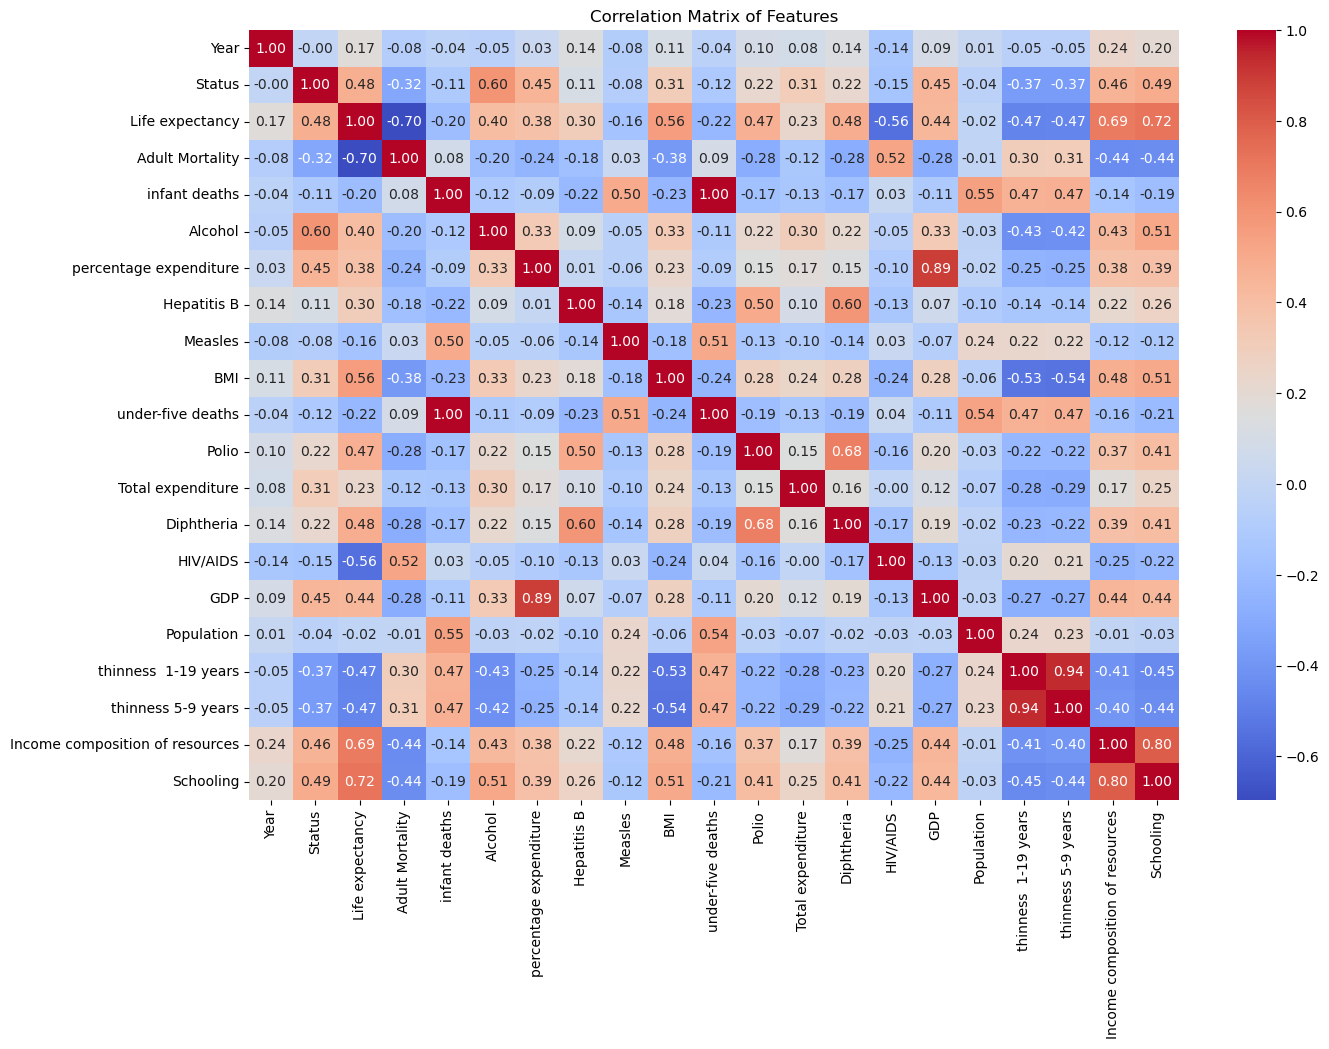

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 10))
sns.heatmap(Df_model.corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation Matrix of Features')
plt.show()

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.25, random_state=11)
print("تقسیم‌بندی داده‌ها با موفقیت انجام شد. شکل ویژگی‌های آموزش:", X_train.shape)

تقسیم‌بندی داده‌ها با موفقیت انجام شد. شکل ویژگی‌های آموزش: (2203, 20)


In [18]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [24]:
# الف) مدل رگرسیون خطی (Linear Regression)
lr_model = LinearRegression()
lr_model.fit(X_train, Y_train)
lr_preds = lr_model.predict(X_test)

# ب) مدل جنگل تصادفی (Random Forest)
rf_model = RandomForestRegressor(n_estimators=100, random_state=11)
rf_model.fit(X_train, Y_train)
rf_preds = rf_model.predict(X_test)

In [25]:
results = {
    "Metric": ["MAE (میانگین خطا)", "MSE (میانگین مجذور خطا)", "R2 Score (دقت مدل)"],
    "Linear Regression": [
        mean_absolute_error(Y_test, lr_preds),
        mean_squared_error(Y_test, lr_preds),
        r2_score(Y_test, lr_preds)
    ],
    "Random Forest": [
        mean_absolute_error(Y_test, rf_preds),
        mean_squared_error(Y_test, rf_preds),
        r2_score(Y_test, rf_preds)
    ]
}

df_results = pd.DataFrame(results)
print(df_results.to_string(index=False))

                 Metric  Linear Regression  Random Forest
      MAE (میانگین خطا)           3.153012       1.191143
MSE (میانگین مجذور خطا)          18.296246       3.759967
     R2 Score (دقت مدل)           0.799162       0.958727


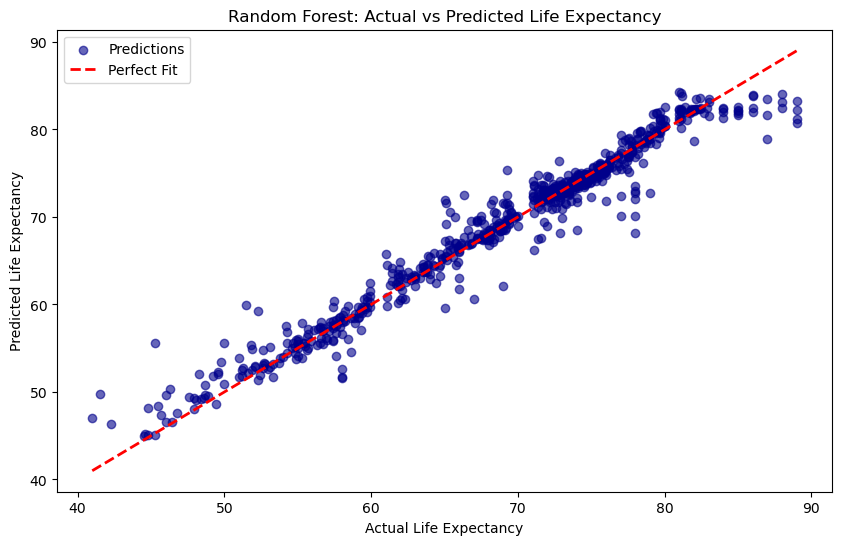

In [26]:
plt.figure(figsize=(10, 6))
plt.scatter(Y_test, rf_preds, alpha=0.6, color='darkblue', label='Predictions')
plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], 'r--', lw=2, label='Perfect Fit')
plt.xlabel('Actual Life Expectancy')
plt.ylabel('Predicted Life Expectancy')
plt.title('Random Forest: Actual vs Predicted Life Expectancy')
plt.legend()
plt.show()